In [154]:
import sys
sys.path.insert(0, 'AstroM3')

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random
from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib
from scipy.interpolate import interp1d
from datetime import datetime
import torch
from scipy import stats

from AstroM3.core.dataset import DataGenerator
from AstroM3.core.model import GalSpecNet

In [2]:
CLASSES = ['SN Ia', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 
           'Tidal Disruption Event']

In [13]:
config = {
    'mode': 'spectra',
    'preprocessed_path': '/data/dev/ml_skyportal/AppleCider/data_train_redux/',
    'spectra_path': '/data/dev/ml_skyportal/AJs_Stuff/(aj)data_all/',
    'df_path': '/data/dev/ml_skyportal/AppleCider/data_train.csv',
    'scaler_path': '/data/dev/ml_skyportal/AppleCider/AstroM3/core/scaler.pkl',
    'step': 'type',
    'classes': CLASSES,
    'num_classes': len(CLASSES),
    'max_samples': 5000,
    'random_seed': 42,
    'group_labels': False,

    # Spectra Model
    's_dropout': 0.2,
    's_conv_channels': [1, 64, 64, 32, 32],
    's_kernel_size': 3,
    's_mp_kernel_size': 4,
}

In [4]:
train_dataset = DataGenerator(config, split='train')
val_dataset = DataGenerator(config, split='val')

Left only with classes: ['SN Ia', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event']
Down sampled class SN Ia from 41084 to 5000
Left only with classes: ['SN Ia', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event']
Down sampled class SN Ia from 41084 to 5000


In [63]:
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=False, drop_last=True, num_workers=4)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False)

In [64]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GalSpecNet(config)
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()

In [145]:
for i in tqdm(range(len(train_dataset))):
    spectra = train_dataset[i][4]
    spectra = torch.tensor(spectra)
    spectra = spectra.unsqueeze(0)
    
    label = train_dataset[i][-1]
    label = torch.tensor(label)
    label = label.unsqueeze(0)
    
    with torch.no_grad():
        spectra, label = spectra.to(device), label.to(device)
        
        logits = model(spectra)
        loss = criterion(logits, label)

        if torch.isnan(loss):
            print(i)
            break

 17%|████████████                                                          | 3138/18211 [00:12<01:00, 247.97it/s]

3138


In [146]:
spectra = train_dataset[3138][4]

In [147]:
spectra

array([[nan, nan, nan, ..., nan, nan, nan]], dtype=float32)

In [182]:
spectra = train_dataset.read_spectra_csv(train_dataset.df.iloc[3138]['name'], 
                                         train_dataset.spectra_path)

In [183]:
spectra.shape

(5100, 2)

In [184]:
spectra = spectra[~np.isnan(spectra).any(axis=1)]

In [185]:
spectra.shape

(5095, 2)

In [186]:
new_wavelength = np.linspace(4500, 7980, 7980 - 4500 + 1)

f = interp1d(spectra[:, 0], spectra[:, 1], kind='linear')
flux = f(new_wavelength)

In [187]:
print("Wavelength range:", spectra[:, 0].min(), spectra[:, 0].max())
print("New wavelength range:", new_wavelength.min(), new_wavelength.max())

Wavelength range: 3105.5581 10303.051
New wavelength range: 4500.0 7980.0


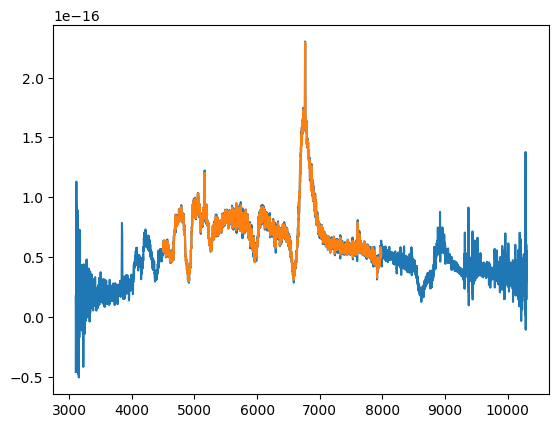

In [191]:
plt.plot(spectra[:, 0], spectra[:, 1])
plt.plot(new_wavelength, flux)

In [192]:
mean = np.mean(flux)
mad = stats.median_abs_deviation(flux)

In [193]:
mean, mad

(np.float64(7.292652672122344e-17), np.float64(1.2008594143024644e-17))